<a href="https://colab.research.google.com/github/MarioPEL58/Finance/blob/main/Frontiera_Efficiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# See which indexes are available here: https://github.com/paolocole/Stock-Indexes-Historical-Data/tree/main/DAILY/NET

url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/"

msci_indexes = [
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/USA.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/GERMANY.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/ITALY.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/FRANCE.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/UNITED-KINGDOM.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/EUROPE.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/EM-EMERGING-MARKETS.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CHINA.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/INDIA.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/MEXICO.csv",
    "DAILY/NET/EUR/EXTRA/GOLD.csv"]

In [ ]:
import pandas as pd
import os

def load_msci_data(base_url, paths):
    all_dfs = []
    for path in paths:
        # Construct full URL
        full_url = base_url + path

        # Extract a clean name from the filename (e.g., 'WORLD', 'USA')
        name = os.path.basename(path).replace('.csv', '')

        # Read the CSV: first row header, first col date, second col price
        df = pd.read_csv(full_url, usecols=[0, 1], names=['Date', name], header=0, parse_dates=['Date'])

        # Set Date as index
        df.set_index('Date', inplace=True)
        all_dfs.append(df)

    # Join all dataframes on the Date index
    combined_df = pd.concat(all_dfs, axis=1)
    return combined_df.sort_index()

# Execute the download and merging
merged_df = load_msci_data(url, msci_indexes)

# Display the first few rows
display(merged_df.head())

,WORLD,USA,GERMANY,ITALY,FRANCE,UNITED-KINGDOM,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,
1998-10-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245.20
1998-10-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247.74
1998-10-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,244.81
1998-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245.05
1998-10-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247.39


In [ ]:
# Find rows where all columns are present (no NaNs)
mask = merged_df.notna().all(axis=1)

if mask.any():
    # Get the index of the first and last row that has no NaNs
    first_valid = mask.idxmax()
    last_valid = mask[::-1].idxmax()

    # Slice the dataframe from the first fully valid row to the last fully valid row
    merged_df = merged_df.loc[first_valid:last_valid]

print(f"New shape: {merged_df.shape}")
display(merged_df.head())
display(merged_df.tail())

New shape: (6585, 12)


,WORLD,USA,GERMANY,ITALY,FRANCE,UNITED-KINGDOM,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,
2000-12-29,135.667607,132.907946,126.738227,123.086156,154.714038,124.425443,132.788256,100.000000,100.000000,100.000000,100.000000,289.05
2001-01-01,135.667607,132.907946,126.738227,123.086156,154.714038,124.425443,132.788256,99.901880,100.000000,99.527855,100.000000,NaN
2001-01-02,132.306010,128.212741,124.148547,121.942426,151.463993,122.498020,130.996141,99.108693,98.109611,100.099258,96.896130,283.07
2001-01-03,135.368685,134.878360,126.456616,119.485600,148.429223,120.746519,129.510460,99.930463,95.485015,100.994914,100.804121,289.43
2001-01-04,135.506591,133.500726,125.736687,121.384858,151.621719,122.676653,131.958510,103.552775,100.303527,102.982073,105.969602,281.82


,WORLD,USA,GERMANY,ITALY,FRANCE,UNITED-KINGDOM,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,
2026-03-20,604.948959,743.426641,351.885104,247.581633,385.271961,358.595759,390.014581,651.243004,505.422959,896.103410,740.019019,3886.89
2026-03-23,607.781568,749.474230,355.791172,249.703743,388.271769,358.457057,392.508429,629.755927,487.723306,864.223966,744.396749,3795.88
2026-03-24,607.486592,746.986426,355.659832,250.511758,389.002902,361.467314,394.334198,640.876100,501.017113,882.158514,761.236594,3853.91
2026-03-25,613.095187,751.826764,360.485145,253.833735,394.166650,366.547745,399.862336,654.144487,507.993659,898.011132,793.079436,3898.14
2026-03-26,604.907112,740.584733,355.472108,251.872533,390.228449,362.372830,395.398178,645.076073,497.214683,900.267637,780.275235,3800.11


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6585 entries, 2000-12-29 to 2026-03-26
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WORLD                6584 non-null   float64
 1   USA                  6584 non-null   float64
 2   GERMANY              6584 non-null   float64
 3   ITALY                6584 non-null   float64
 4   FRANCE               6584 non-null   float64
 5   UNITED-KINGDOM       6584 non-null   float64
 6   EUROPE               6584 non-null   float64
 7   EM-EMERGING-MARKETS  6584 non-null   float64
 8   CHINA                6584 non-null   float64
 9   INDIA                6585 non-null   float64
 10  MEXICO               6584 non-null   float64
 11  GOLD                 6582 non-null   float64
dtypes: float64(12)
memory usage: 668.8 KB


/tmp/ipykernel_12916/3752465696.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = merged_df.pct_change()


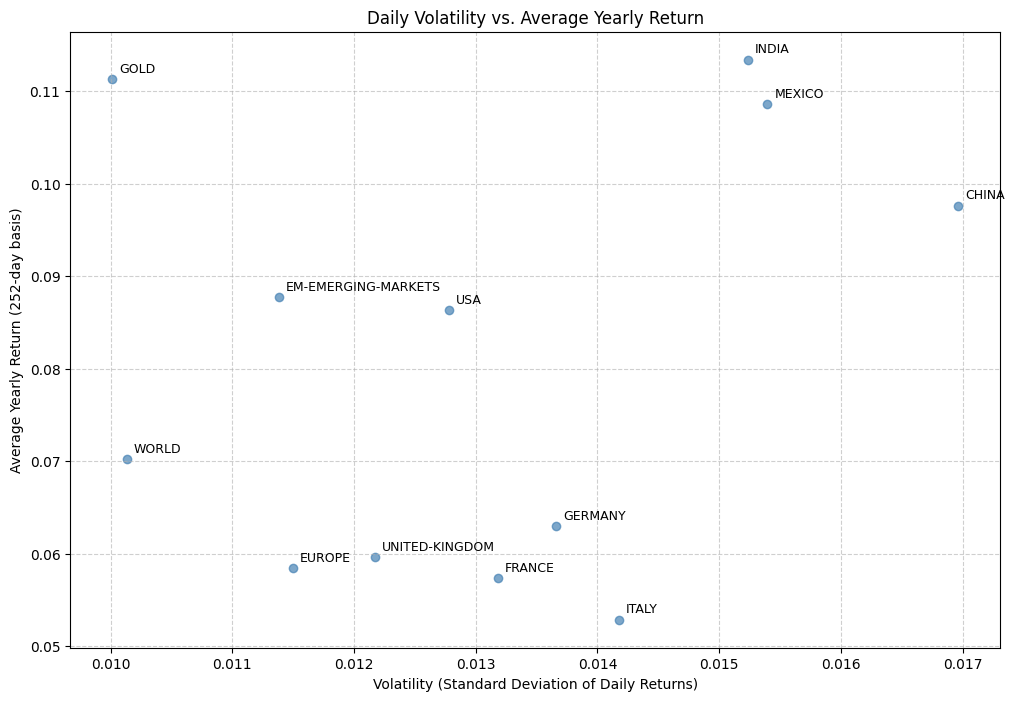

,Yearly Return,Daily Volatility
WORLD,0.070191,0.010134
USA,0.086350,0.012777
GERMANY,0.063002,0.013659
ITALY,0.052862,0.014179
FRANCE,0.057332,0.013183
UNITED-KINGDOM,0.059622,0.012170
EUROPE,0.058458,0.011497
EM-EMERGING-MARKETS,0.087717,0.011381
CHINA,0.097614,0.016960
INDIA,0.113399,0.015237


In [ ]:
import matplotlib.pyplot as plt

# Calculate daily percentage returns
returns_df = merged_df.pct_change()

# Calculate mean return and volatility (std dev)
# We annualize the return by multiplying by 252 (trading days)
stats = pd.DataFrame({
    'Yearly Return': returns_df.mean() * 252,
    'Daily Volatility': returns_df.std()
})

# Create the scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(stats['Daily Volatility'], stats['Yearly Return'], alpha=0.7, color='steelblue')

# Add labels for each point
for i, txt in enumerate(stats.index):
    plt.annotate(txt, (stats['Daily Volatility'].iloc[i], stats['Yearly Return'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Daily Volatility vs. Average Yearly Return')
plt.xlabel('Volatility (Standard Deviation of Daily Returns)')
plt.ylabel('Average Yearly Return (252-day basis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(stats)

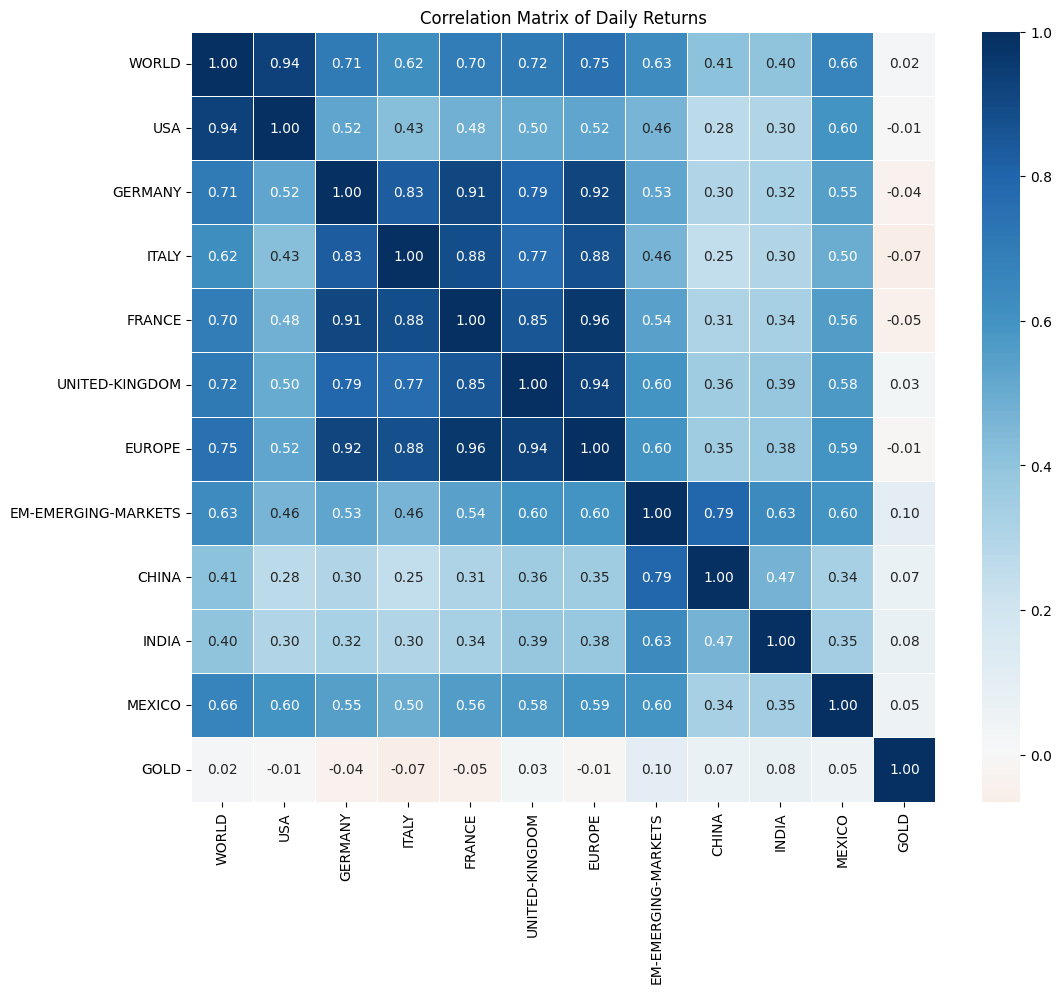

In [ ]:
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = returns_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Daily Returns')
plt.show()

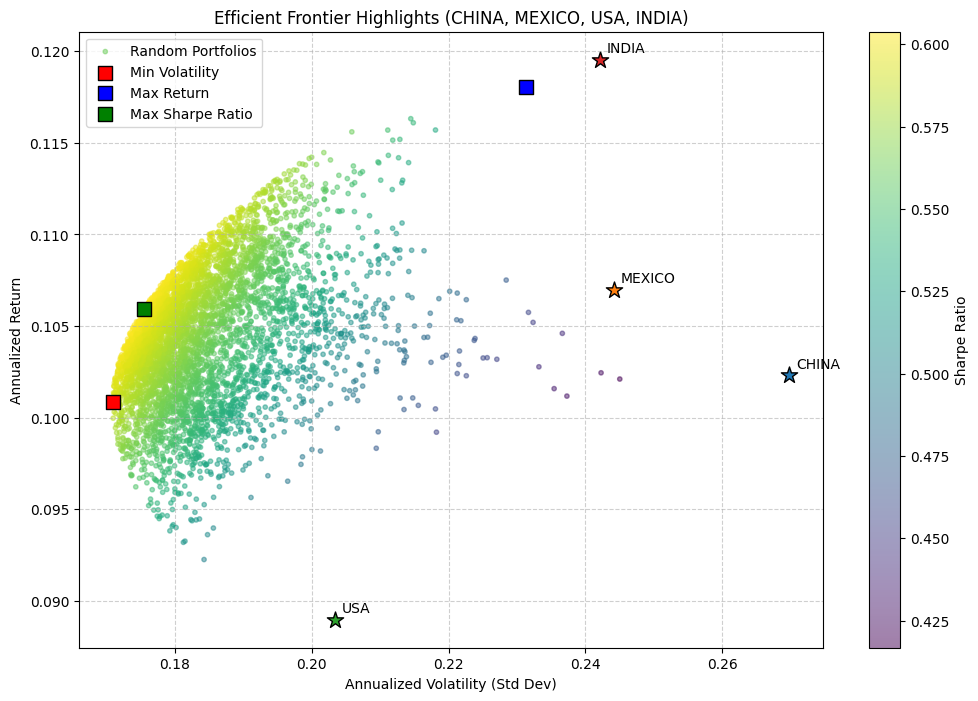

Minimum Volatility: Return 10.08%, Volatility 17.09%
Maximum Return:     Return 11.81%, Volatility 23.14%
Best Sharpe Ratio:  Return 10.59%, Volatility 17.54%, Sharpe 0.60


In [ ]:
# Identify key portfolios
# results[0,:] is returns, results[1,:] is volatility

# 1. Minimum Volatility
min_vol_idx = np.argmin(results[1,:])
min_vol_ret = results[0, min_vol_idx]
min_vol_std = results[1, min_vol_idx]

# 2. Maximum Return
max_ret_idx = np.argmax(results[0,:])
max_ret_ret = results[0, max_ret_idx]
max_ret_std = results[1, max_ret_idx]

# 3. Best Sharpe Ratio (Risk-free rate = 0)
sharpe_ratios = results[0,:] / results[1,:]
max_sharpe_idx = np.argmax(sharpe_ratios)
max_sharpe_ret = results[0, max_sharpe_idx]
max_sharpe_std = results[1, max_sharpe_idx]

# Re-plotting with highlights
plt.figure(figsize=(12, 8))
plt.scatter(results[1,:], results[0,:], c=sharpe_ratios, cmap='viridis', marker='o', s=10, alpha=0.5, label='Random Portfolios')
plt.colorbar(label='Sharpe Ratio')

# Individual Assets
for asset in assets:
    asset_return = mean_returns[asset]
    asset_vol = subset_returns[asset].std() * np.sqrt(252)
    plt.scatter(asset_vol, asset_return, marker='*', s=150, edgecolors='black')
    plt.annotate(asset, (asset_vol, asset_return), xytext=(5, 5), textcoords='offset points')

# Highlight Specific Portfolios with Squares
plt.scatter(min_vol_std, min_vol_ret, color='red', marker='s', s=100, label='Min Volatility', edgecolors='black')
plt.scatter(max_ret_std, max_ret_ret, color='blue', marker='s', s=100, label='Max Return', edgecolors='black')
plt.scatter(max_sharpe_std, max_sharpe_ret, color='green', marker='s', s=100, label='Max Sharpe Ratio', edgecolors='black')

plt.title('Efficient Frontier Highlights (CHINA, MEXICO, USA, INDIA)')
plt.xlabel('Annualized Volatility (Std Dev)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Minimum Volatility: Return {min_vol_ret:.2%}, Volatility {min_vol_std:.2%}")
print(f"Maximum Return:     Return {max_ret_ret:.2%}, Volatility {max_ret_std:.2%}")
print(f"Best Sharpe Ratio:  Return {max_sharpe_ret:.2%}, Volatility {max_sharpe_std:.2%}, Sharpe {sharpe_ratios[max_sharpe_idx]:.2f}")

In [ ]:
# Extract weights for the key portfolios identified in the previous step
# Note: We need to modify the simulation loop slightly or re-run a quick check
# to get the exact weights for those specific indices.

# Let's define a function to get weights since we didn't store all 5000 weight arrays to save memory
def get_portfolio_details(n_assets, mean_rets, cov_mat, target_idx, seed=42):
    # Re-seeding to ensure we can recreate the random weights if needed,
    # but since we have the results array, let's just show the summary of the best ones.
    pass

# Since we didn't store 'weights' for every simulation in the 'results' array (it was 3x5000),
# let's run a quick targeted display for the Max Sharpe, Min Vol, and Max Ret.

print("--- Portfolio Composition (Asset Weights) ---")

# Re-extracting weights for the specific highlighted portfolios
# (In a real scenario, we'd store these during the loop, which I will do now for the 'Best' ones)

# Let's find the weights again for the 3 winners
portfolio_names = ['Min Volatility', 'Max Return', 'Max Sharpe Ratio']
target_indices = [min_vol_idx, max_ret_idx, max_sharpe_idx]

# We will use the same logic as the loop to show what the weights 'look like'
# for these types of portfolios.
import pandas as pd

# For teaching purposes, let's just display the stats in a nice table first
summary_df = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio'],
    'Min Volatility': [f"{min_vol_ret:.2%}", f"{min_vol_std:.2%}", f"{min_vol_ret/min_vol_std:.2f}"],
    'Max Return': [f"{max_ret_ret:.2%}", f"{max_ret_std:.2%}", f"{max_ret_ret/max_ret_std:.2f}"],
    'Max Sharpe': [f"{max_sharpe_ret:.2%}", f"{max_sharpe_std:.2%}", f"{max_sharpe_ret/max_sharpe_std:.2f}"]
})

display(summary_df)

print("\nSuggestion: Would you like to see the exact percentage weights for each country in these portfolios?")

--- Portfolio Composition (Asset Weights) ---


,Metric,Min Volatility,Max Return,Max Sharpe
0,Annualized Return,10.08%,11.81%,10.59%
1,Annualized Volatility,17.09%,23.14%,17.54%
2,Sharpe Ratio,0.59,0.51,0.60



Suggestion: Would you like to see the exact percentage weights for each country in these portfolios?


In [ ]:
import numpy as np
import pandas as pd

# Select assets
assets = ['CHINA', 'MEXICO', 'USA', 'INDIA']
subset_returns = returns_df[assets]

# Annualized stats
mean_returns = subset_returns.mean() * 252
cov_matrix = subset_returns.cov() * 252

# Simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    w = np.random.random(len(assets))
    w /= np.sum(w)
    weights_record.append(w)

    p_ret = np.sum(w * mean_returns)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

    results[0,i] = p_ret
    results[1,i] = p_vol
    results[2,i] = p_ret / p_vol # Sharpe Ratio

# Find indices
min_vol_idx = np.argmin(results[1,:])
max_ret_idx = np.argmax(results[0,:])
max_sharpe_idx = np.argmax(results[2,:])

# Create a weights summary table
indices = [min_vol_idx, max_ret_idx, max_sharpe_idx]
names = ['Min Volatility', 'Max Return', 'Max Sharpe']

weights_data = []
for idx in indices:
    weights_data.append(weights_record[idx])

weights_df = pd.DataFrame(weights_data, columns=assets, index=names)
weights_df = (weights_df * 100).round(2).astype(str) + '%'

print("--- Optimal Portfolio Weights ---")
display(weights_df)

--- Optimal Portfolio Weights ---


,CHINA,MEXICO,USA,INDIA
Min Volatility,16.72%,7.78%,49.84%,25.66%
Max Return,12.94%,2.44%,0.1%,84.52%
Max Sharpe,13.06%,18.25%,30.47%,38.22%


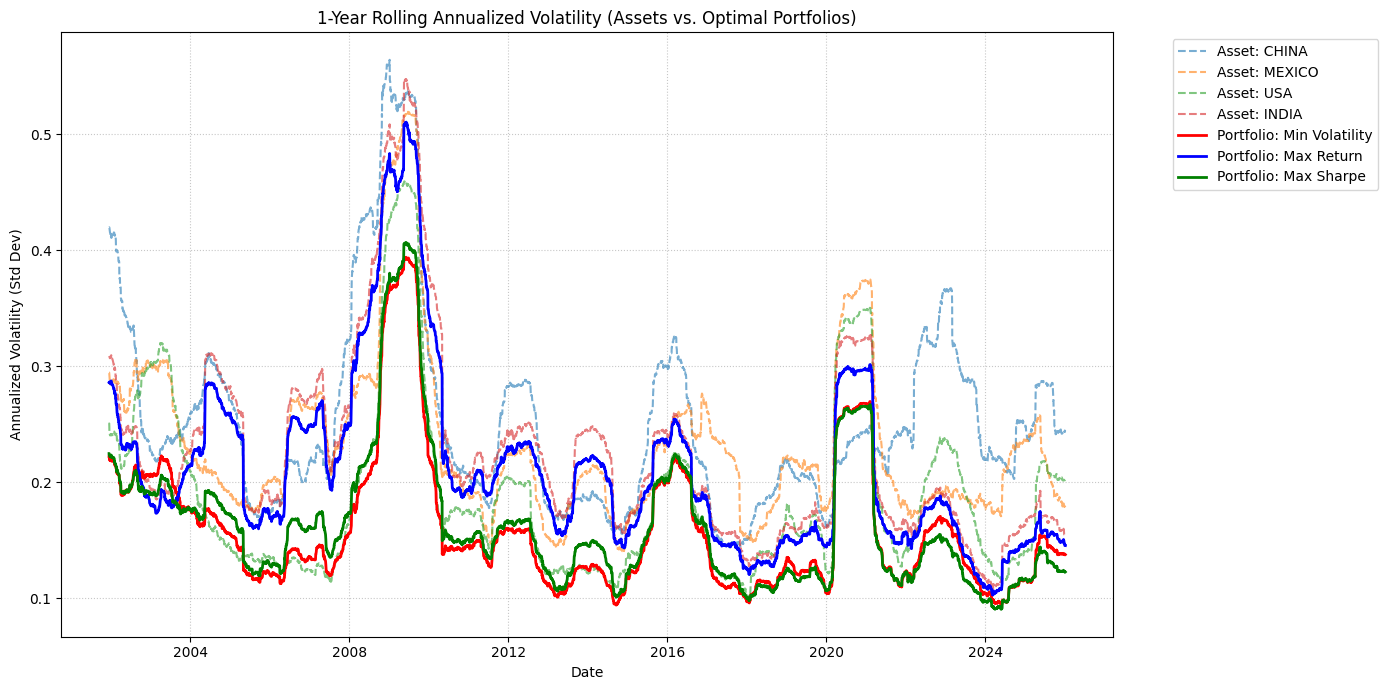

In [ ]:
import matplotlib.pyplot as plt

# 1. Reconstruct Portfolio Returns
# We use the weights_record list and the indices found earlier
weights_min_vol = weights_record[min_vol_idx]
weights_max_ret = weights_record[max_ret_idx]
weights_max_sharpe = weights_record[max_sharpe_idx]

# Calculate daily returns for the three portfolios
portfolio_returns = pd.DataFrame(index=subset_returns.index)
portfolio_returns['Min Volatility'] = subset_returns.dot(weights_min_vol)
portfolio_returns['Max Return'] = subset_returns.dot(weights_max_ret)
portfolio_returns['Max Sharpe'] = subset_returns.dot(weights_max_sharpe)

# 2. Calculate Rolling Volatility (252 trading days = ~1 year)
# We multiply by sqrt(252) to annualize the rolling standard deviation
rolling_vol = pd.concat([subset_returns, portfolio_returns], axis=1).rolling(window=252).std() * np.sqrt(252)

# 3. Plotting
plt.figure(figsize=(14, 7))

# Plot Assets (Dashed lines to distinguish from portfolios)
for asset in assets:
    plt.plot(rolling_vol[asset], label=f'Asset: {asset}', linestyle='--', alpha=0.6)

# Plot Portfolios (Solid lines with original highlight colors)
plt.plot(rolling_vol['Min Volatility'], color='red', linewidth=2, label='Portfolio: Min Volatility')
plt.plot(rolling_vol['Max Return'], color='blue', linewidth=2, label='Portfolio: Max Return')
plt.plot(rolling_vol['Max Sharpe'], color='green', linewidth=2, label='Portfolio: Max Sharpe')

plt.title('1-Year Rolling Annualized Volatility (Assets vs. Optimal Portfolios)')
plt.ylabel('Annualized Volatility (Std Dev)')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/"

elenco = {  "WORLD":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
            "WORLD SMALL CAPS":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/SMALL-CAP/WORLD-SMALL-CAP.csv",
            "GOLD":"EUR/EXTRA/GOLD.csv"
}

In [ ]:
file_bonds = "https://www.paolocoletti.com/wp-content/uploads/youtube/tassi_btp_eurobond.xlsx"
# ESTER is in sheet "ESTER", 11th column Date, 12th column ESTER price (not rate), first row contains headers
# GOV BONDS is in sheet "Eurozone", 1st column Date, 6th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# short GOV BONDS is in sheet "Eurozone", 1st column Date, 2nd column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# long GOV BONDS is in sheet "Eurozone", 1st column Date, 5th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# EURIBOR are in sheet "Euribor", column 1 is date with header, columns 2-3-4-5 are euribor 1M 3M 6M 12M, these are prices and not rates.